# Pseudobulk Differential Expression + Ranked GSEA

Compare two conditions within a chosen cell population, then identify differentially expressed genes and enriched pathways.

**Sign convention:** `condition_a` (the first condition you list below) is the *reference for upregulation*. Positive log2FC and positive NES both mean **higher in `condition_a`**.

## Imports

In [1]:
# pip install pydeseq2 gseapy   # if not yet installed

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import anndata as ad
import spatialdata as spd

import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import gseapy as gp

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Configuration

Edit the blocks below to control what is compared. Everything downstream reads from these variables.

In [2]:
# ============================================================================
# ── CELLS, CONDITIONS, SAMPLES (edit this block) ────────────────────────────
# ============================================================================

# --- Cells of interest ------------------------------------------------------
# The annotation column and the cell types you want to pool for the DE.
# Multiple cell types are treated as a single population.
celltype_col     = "c2l_permissive"
focus_cell_types = ["NK"]              # e.g. ["NK"] or ["CD8_T", "NK"]

# --- Conditions to compare --------------------------------------------------
# IMPORTANT: condition_a is the reference for upregulation.
# Positive log2FC and positive NES => UP in condition_a.
condition_col = "treatment"
condition_a   = "RTCyPSCA_Tu1"      # numerator → "up" direction
condition_b   = "CyPSCA_Tu1"    # denominator

# --- Replicate / pseudobulk grouping ----------------------------------------
# Each unique value in this column becomes one pseudobulk sample.
sample_col    = "tissue"

# --- Optional tissue exclusion ----------------------------------------------
apply_exclusion = False
exclude_tissues = [
    # "CyPSCA_1_3",
    # "RTCyPSCA_1_2",
]

# --- Pseudobulk / DE thresholds --------------------------------------------
min_cells_per_sample = 10     # drop pseudobulk samples with fewer cells
min_total_counts     = 10     # drop genes with low total counts across samples

# --- Output directory -------------------------------------------------------
outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pseudobulk_de")
outdir.mkdir(parents=True, exist_ok=True)

# ============================================================================

print(f"Comparison:  {condition_a}  (positive LFC = up here)  vs  {condition_b}")
print(f"Cell types:  {focus_cell_types}  (column: {celltype_col})")
print(f"Sample col:  {sample_col}")
if apply_exclusion and exclude_tissues:
    print(f"Excluding tissues: {exclude_tissues}")
print(f"Output:      {outdir}")

Comparison:  RTCyPSCA_Tu1  (positive LFC = up here)  vs  CyPSCA_Tu1
Cell types:  ['NK']  (column: c2l_permissive)
Sample col:  tissue
Output:      /coh_labs/yunroseli/Jona/CAR-T/results/pseudobulk_de


## Pathways

In [44]:
# ============================================================================
# ── PATHWAY DATABASES FOR GSEA (edit this block) ────────────────────────────
# ============================================================================

# All available GMT files. Add new entries here as needed.
pathway_libs = {
    "hallmark": Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/mh.all.v2026.1.Mm.symbols.gmt"),
    "reactome": Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.reactome.v2026.1.Mm.symbols.gmt"),
    "go_bp":    Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m5.go.bp.v2026.1.Mm.symbols.gmt"),
    # "kegg":   Path("/path/to/another.gmt"),
}

# Pick which of the above to include in the GSEA prerank.
selected_libs = ["go_bp"]    # e.g. ["hallmark", "reactome"]

# ============================================================================

def read_gmt(gmt_path):
    sets = {}
    with open(gmt_path) as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            sets[parts[0]] = parts[2:]
    return sets

gene_sets = {}
for lib in selected_libs:
    path = pathway_libs[lib]
    if not path.exists():
        print(f"WARNING: missing GMT for '{lib}': {path}")
        continue
    sets = read_gmt(path)
    print(f"  {lib}: {len(sets):,} sets from {path.name}")
    # Track origin so we can colour bars later
    for k, v in sets.items():
        gene_sets[k] = v

# Lookup table: pathway name -> source library
pathway_source = {}
for lib in selected_libs:
    if pathway_libs[lib].exists():
        for k in read_gmt(pathway_libs[lib]).keys():
            pathway_source.setdefault(k, lib)

print(f"\nTotal gene sets for GSEA: {len(gene_sets):,}")

  go_bp: 7,781 sets from m5.go.bp.v2026.1.Mm.symbols.gmt

Total gene sets for GSEA: 7,781


## Load data

In [4]:
zarr_file = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]

# Preserve raw counts in a layer so pseudobulk uses untransformed counts later,
# regardless of any normalization done elsewhere.
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

print(adata)

AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'treatment'
    uns: 'spatialdata_attrs'
    obsm: 'c2l_q05', 'spatial', 'c2l_means', 'c2l_q95'
    layers: 'counts'


## QC: filter low-quality cells

Drop cells with very low UMI counts, very few detected genes, or high mitochondrial fraction. Histograms show distributions with the chosen thresholds (red dashed lines) — adjust thresholds based on what you see.

Mitochondrial genes detected (prefix 'mt-'): 13

Before QC: 2,088,557 cells


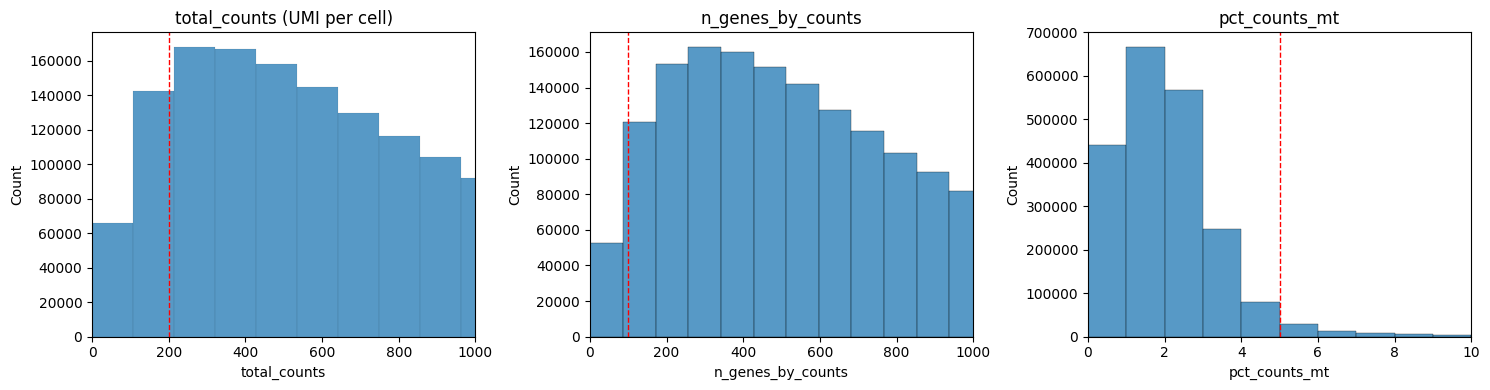

In [31]:
# ── QC thresholds (edit this block) ──────────────────────────────────────────
mt_prefix    = "mt-"     # mouse: "mt-"   human: "MT-"
min_counts   = 200       # min total UMI counts per cell
min_genes    = 100        # min genes detected per cell
max_pct_mt   = 5        # max % mitochondrial reads per cell
# ─────────────────────────────────────────────────────────────────────────────

adata.var["mt"] = adata.var_names.str.startswith(mt_prefix)
print(f"Mitochondrial genes detected (prefix '{mt_prefix}'): {adata.var['mt'].sum()}")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

print(f"\nBefore QC: {adata.n_obs:,} cells")

# Distribution plots with threshold lines
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(adata.obs["total_counts"], bins=500, ax=axes[0])
axes[0].axvline(min_counts, color="red", ls="--", lw=1)
axes[0].set_title("total_counts (UMI per cell)")
# axes[0].set_xscale("log")
axes[0].set_xlim(0, 1000)

sns.histplot(adata.obs["n_genes_by_counts"], bins=100, ax=axes[1])
axes[1].axvline(min_genes, color="red", ls="--", lw=1)
axes[1].set_title("n_genes_by_counts")
axes[1].set_xlim(0,1000)

sns.histplot(adata.obs["pct_counts_mt"], bins=100, ax=axes[2])
axes[2].axvline(max_pct_mt, color="red", ls="--", lw=1)
axes[2].set_title("pct_counts_mt")
axes[2].set_xlim(0,10)

plt.tight_layout()
plt.show()


In [32]:

# Apply filters
fail_counts = adata.obs["total_counts"]      < min_counts
fail_genes  = adata.obs["n_genes_by_counts"] < min_genes
fail_mt     = adata.obs["pct_counts_mt"]     > max_pct_mt
keep        = ~(fail_counts | fail_genes | fail_mt)

print(f"\nDropped:")
print(f"  low counts (< {min_counts}):     {fail_counts.sum():,}")
print(f"  low genes  (< {min_genes}):      {fail_genes.sum():,}")
print(f"  high mt    (> {max_pct_mt}%):    {fail_mt.sum():,}")
print(f"  total dropped (union):         {(~keep).sum():,}")

adata = adata[keep].copy()

print(f"\nAfter QC: {adata.n_obs:,} cells")


Dropped:
  low counts (< 200):     186,506
  low genes  (< 100):      67,257
  high mt    (> 5%):    84,187
  total dropped (union):         237,332

After QC: 1,851,225 cells


## Normalize

Normalize `adata.X` to 1e4 counts per cell and log1p-transform. **Raw counts are preserved in `adata.layers["counts"]`** and the pseudobulk + DE steps use that layer directly, so DESeq2 sees untransformed counts as required.

In [33]:
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
sc.pp.log1p(adata)

adata.uns["normalization"] = {
    "method": "scanpy.pp.normalize_total + log1p",
    "target_sum": 1e4,
    "raw_counts_layer": "counts",
}

print("Normalized adata.X (1e4 + log1p). Raw counts still in adata.layers['counts'].")

Normalized adata.X (1e4 + log1p). Raw counts still in adata.layers['counts'].


## Subset to cells of interest

In [34]:
ct_mask   = adata.obs[celltype_col].astype(str).isin(focus_cell_types)
cond_mask = adata.obs[condition_col].astype(str).isin([condition_a, condition_b])

if apply_exclusion and exclude_tissues:
    tissue_mask = ~adata.obs[sample_col].astype(str).isin(exclude_tissues)
else:
    tissue_mask = np.ones(adata.n_obs, dtype=bool)

adata_sub = adata[ct_mask & cond_mask & tissue_mask].copy()

print(f"Cells after filtering: {adata_sub.n_obs:,}")
print()
print("Cells per (condition, sample):")
print(
    adata_sub.obs
    .groupby([condition_col, sample_col], observed=True)
    .size()
    .to_frame("n_cells")
)

Cells after filtering: 3,813

Cells per (condition, sample):
                           n_cells
treatment    tissue               
CyPSCA_Tu1   CyPSCA_1_1       2371
             CyPSCA_1_2        721
             CyPSCA_1_3        247
             CyPSCA_1_4        251
RTCyPSCA_Tu1 RTCyPSCA_1_2       34
             RTCyPSCA_1_3      102
             RTCyPSCA_1_4       77
             RTCyPSCA_1_5       10


## Pseudobulk

Sum **raw counts** across cells, grouped by sample. Samples with fewer than `min_cells_per_sample` cells are dropped.

In [35]:
X = adata_sub.layers["counts"]
if sp.issparse(X):
    X = X.toarray()

sample_keys    = adata_sub.obs[sample_col].astype(str).values
condition_keys = adata_sub.obs[condition_col].astype(str).values

# Cells per sample
n_per_sample = pd.Series(sample_keys).value_counts()
valid_samples = n_per_sample[n_per_sample >= min_cells_per_sample].index.tolist()
dropped = n_per_sample[n_per_sample < min_cells_per_sample].to_dict()
if dropped:
    print(f"Dropped samples (< {min_cells_per_sample} cells): {dropped}")

# Build pseudobulk count matrix and metadata
pb_rows = []
pb_meta = []
for s in valid_samples:
    mask = sample_keys == s
    pb_rows.append(X[mask].sum(axis=0))
    pb_meta.append({
        sample_col:    s,
        condition_col: condition_keys[mask][0],
        "n_cells":     int(mask.sum()),
    })

pb_counts_df = pd.DataFrame(
    np.vstack(pb_rows),
    columns=adata_sub.var_names,
    index=[m[sample_col] for m in pb_meta],
).astype(int)
pb_meta_df = pd.DataFrame(pb_meta).set_index(sample_col)

# Drop low-count genes
gene_totals = pb_counts_df.sum(axis=0)
keep_genes  = gene_totals >= min_total_counts
pb_counts_df = pb_counts_df.loc[:, keep_genes]

print(f"Pseudobulk samples: {len(pb_counts_df)}")
print(f"Genes after filter (>= {min_total_counts} total counts): {pb_counts_df.shape[1]:,}")
print()
print("Samples per condition:")
print(pb_meta_df.groupby(condition_col).size())
display(pb_meta_df)

Pseudobulk samples: 8
Genes after filter (>= 10 total counts): 11,443

Samples per condition:
treatment
CyPSCA_Tu1      4
RTCyPSCA_Tu1    4
dtype: int64


,treatment,n_cells
tissue,,
CyPSCA_1_1,CyPSCA_Tu1,2371
CyPSCA_1_2,CyPSCA_Tu1,721
CyPSCA_1_4,CyPSCA_Tu1,251
CyPSCA_1_3,CyPSCA_Tu1,247
RTCyPSCA_1_3,RTCyPSCA_Tu1,102
RTCyPSCA_1_4,RTCyPSCA_Tu1,77
RTCyPSCA_1_2,RTCyPSCA_Tu1,34
RTCyPSCA_1_5,RTCyPSCA_Tu1,10


## Differential expression (PyDESeq2)

In [36]:
dds = DeseqDataSet(
    counts=pb_counts_df,
    metadata=pb_meta_df,
    design_factors=condition_col,
    refit_cooks=True,
)
dds.deseq2()

# contrast = [factor, numerator, denominator]  →  log2(numerator / denominator)
# We put condition_a as numerator so positive LFC = UP in condition_a.
ds = DeseqStats(dds, contrast=[condition_col, condition_a, condition_b])
ds.summary()

de_results = (
    ds.results_df
    .dropna(subset=["padj"])
    .sort_values("padj")
)

n_sig    = (de_results["padj"] < 0.05).sum()
n_up_a   = ((de_results["padj"] < 0.05) & (de_results["log2FoldChange"] > 0)).sum()
n_up_b   = ((de_results["padj"] < 0.05) & (de_results["log2FoldChange"] < 0)).sum()

print(f"\nTotal genes tested: {len(de_results):,}")
print(f"Significant (padj < 0.05): {n_sig}")
print(f"  up in {condition_a}: {n_up_a}")
print(f"  up in {condition_b}: {n_up_b}")

de_csv = outdir / f"DE_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.csv"
de_results.to_csv(de_csv)
print(f"\nSaved: {de_csv}")
display(de_results.head(20))

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_461635/2958885072.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.35 seconds.

Fitting dispersion trend curve...
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 1.36 seconds.

Fitting LFCs...
... done in 1.04 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: treatment RTCyPSCA_Tu1 vs CyPSCA_Tu1
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Lypla1    11.567036        0.022237  0.409889  0.054251  0.956735  0.999521
Tcea1     30.189009       -0.326597  0.299208 -1.091538  0.275036  0.999521
Atp6v1h   31.752922       -0.113385  0.307543 -0.368680  0.712366  0.999521
Rb1cc1     8.430326        0.442180  0.461161  0.958840  0.337639  0.999521
Pcmtd1    11.245461        0.427125  0.422218  1.011621  0.311719  0.999521
...             ...             ...       ...       ...       ...       ...
mt-Nd4   146.933973       -0.227681  0.168572 -1.350643  0.176810  0.999521
mt-Nd5   140.662109       -0.121076  0.222044 -0.545279  0.585562  0.999521
mt-Nd6    27.609647       -0.166028  0.295639 -0.561589  0.574396  0.999521
mt-Cytb  531.708430       -0.099759  0.268452 -0.371609  0.710184  0.999521
Vamp7      8.313265       -0.094360  0.627016 -0.150491  0.880377  0.999521

[11443 rows 

... done in 0.69 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Car3,3.934477,6.984255,1.302975,5.360236,8.311342e-08,0.000951
Mybpc1,5.580507,4.095166,0.787452,5.200529,1.987218e-07,0.001137
Trdn,1.684346,4.398256,1.022985,4.299432,1.712363e-05,0.065315
Csf2,3.196963,4.299202,1.022677,4.203872,2.623874e-05,0.075062
Saa3,6.471765,2.969601,0.717038,4.141481,3.450698e-05,0.078973
Cd8b1,2.226758,4.129398,1.019723,4.049527,5.132120e-05,0.097878
Slco4a1,8.963559,2.519020,0.632749,3.981071,6.860547e-05,0.112150
Atp1a2,4.019989,3.617125,0.936369,3.862929,1.120357e-04,0.160253
Tnnt3,10.174490,2.535250,0.676754,3.746193,1.795384e-04,0.228273
Actr2,28.071171,1.191554,0.322484,3.694926,2.199513e-04,0.251690


In [47]:
display(de_results.head(50))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Car3,3.934477,6.984255,1.302975,5.360236,8.311342e-08,0.000951
Mybpc1,5.580507,4.095166,0.787452,5.200529,1.987218e-07,0.001137
Trdn,1.684346,4.398256,1.022985,4.299432,1.712363e-05,0.065315
Csf2,3.196963,4.299202,1.022677,4.203872,2.623874e-05,0.075062
Saa3,6.471765,2.969601,0.717038,4.141481,3.450698e-05,0.078973
Cd8b1,2.226758,4.129398,1.019723,4.049527,5.132120e-05,0.097878
Slco4a1,8.963559,2.519020,0.632749,3.981071,6.860547e-05,0.112150
Atp1a2,4.019989,3.617125,0.936369,3.862929,1.120357e-04,0.160253
Tnnt3,10.174490,2.535250,0.676754,3.746193,1.795384e-04,0.228273
Actr2,28.071171,1.191554,0.322484,3.694926,2.199513e-04,0.251690


## Explore DE genes

Edit the thresholds and `gene_search` to pull out genes of interest.

In [37]:
# ── Editable thresholds ──────────────────────────────────────────────────────
pval_thresh  = 0.05      # padj cutoff
lfc_thresh   = 1.0       # |log2FC| > this
top_n_show   = 30        # rows to display below
gene_search  = []        # e.g. ["Gzmb", "Ifng"]  — look up specific genes
# ─────────────────────────────────────────────────────────────────────────────

sig    = de_results[(de_results["padj"] < pval_thresh) & (de_results["log2FoldChange"].abs() > lfc_thresh)]
up_a   = sig[sig["log2FoldChange"] > 0].sort_values("log2FoldChange", ascending=False)
up_b   = sig[sig["log2FoldChange"] < 0].sort_values("log2FoldChange", ascending=True)

print(f"Up in {condition_a} (top {top_n_show}):")
display(up_a.head(top_n_show))

print(f"\nUp in {condition_b} (top {top_n_show}):")
display(up_b.head(top_n_show))

if gene_search:
    print(f"\nSpecific gene lookup:")
    hits = de_results.loc[de_results.index.isin(gene_search)]
    display(hits)

Up in RTCyPSCA_Tu1 (top 30):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Car3,3.934477,6.984255,1.302975,5.360236,8.311342e-08,0.000951
Mybpc1,5.580507,4.095166,0.787452,5.200529,1.987218e-07,0.001137



Up in CyPSCA_Tu1 (top 30):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj


## Volcano plot

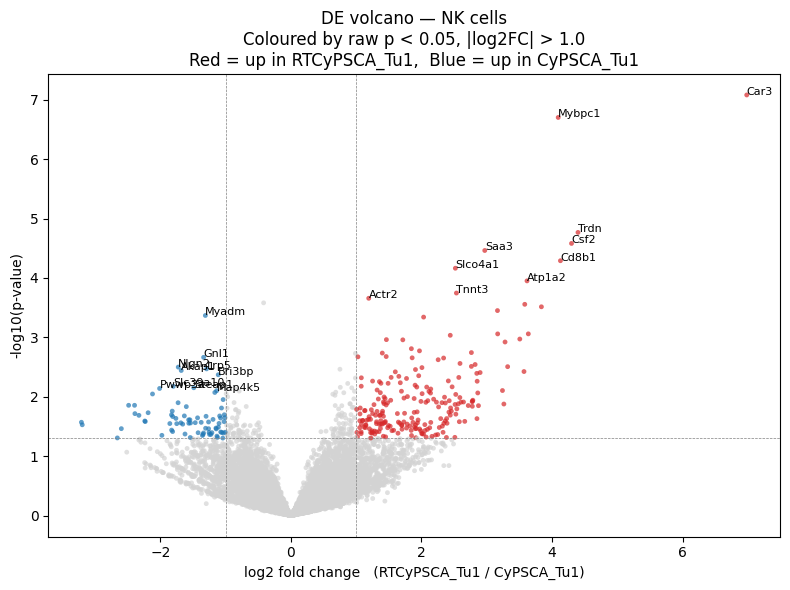

In [38]:
df = de_results.dropna(subset=["pvalue", "log2FoldChange"]).copy()
df["neg_log10_pval"] = -np.log10(df["pvalue"].clip(lower=1e-300))

# Colour by raw p-value (matches the y-axis), not padj.
sig_mask = (df["pvalue"] < pval_thresh) & (df["log2FoldChange"].abs() > lfc_thresh)
color = np.where(
    sig_mask & (df["log2FoldChange"] > 0), "#d62728",         # red    → up in a
    np.where(sig_mask & (df["log2FoldChange"] < 0), "#1f77b4", # blue   → up in b
             "lightgrey"))

# Label the top 10 in each direction by raw p-value among significant genes
sig_df    = df[sig_mask]
label_up  = sig_df[sig_df["log2FoldChange"] > 0].nsmallest(10, "pvalue")
label_dn  = sig_df[sig_df["log2FoldChange"] < 0].nsmallest(10, "pvalue")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["log2FoldChange"], df["neg_log10_pval"], c=color, s=12, alpha=0.7, edgecolors="none")

for gene, row in pd.concat([label_up, label_dn]).iterrows():
    ax.annotate(
        gene,
        (row["log2FoldChange"], -np.log10(max(row["pvalue"], 1e-300))),
        fontsize=8,
    )

ax.axhline(-np.log10(pval_thresh), ls="--", c="grey", lw=0.5)
ax.axvline( lfc_thresh, ls="--", c="grey", lw=0.5)
ax.axvline(-lfc_thresh, ls="--", c="grey", lw=0.5)

ax.set_xlabel(f"log2 fold change   ({condition_a} / {condition_b})")
ax.set_ylabel("-log10(p-value)")
ax.set_title(
    f"DE volcano — {' + '.join(focus_cell_types)} cells\n"
    f"Coloured by raw p < {pval_thresh}, |log2FC| > {lfc_thresh}\n"
    f"Red = up in {condition_a},  Blue = up in {condition_b}"
)
plt.tight_layout()
plt.show()

fig.savefig(outdir / f"volcano_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.png",
            dpi=200, bbox_inches="tight")

## Ranked GSEA (prerank)

Genes are ranked by `sign(log2FC) × -log10(pvalue)`, which combines fold-change **direction** with statistical **significance**. Positive NES means the pathway is enriched at the top of the ranked list — i.e. **up in `condition_a`**.

In [45]:
rank_df = (
    de_results
    .dropna(subset=["log2FoldChange", "pvalue"])
    .copy()
)
pvals = rank_df["pvalue"].clip(lower=1e-300)
rank_df["score"] = np.sign(rank_df["log2FoldChange"]) * -np.log10(pvals)

rnk = (
    rank_df[["score"]]
    .reset_index()
    .rename(columns={rank_df.index.name or "index": "gene"})
    .sort_values("score", ascending=False)
    .drop_duplicates(subset="gene")
)

pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=gene_sets,
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42,
    verbose=False,
)

gsea_df = pre_res.res2d.copy()

# Some gseapy versions return numeric columns as object dtype — coerce them.
for col in ("ES", "NES", "NOM p-val", "FDR q-val", "FWER p-val"):
    if col in gsea_df.columns:
        gsea_df[col] = pd.to_numeric(gsea_df[col], errors="coerce")

# Normalize the pathway-name column across gseapy versions
if "Term" in gsea_df.columns:
    gsea_df = gsea_df.rename(columns={"Term": "pathway"})
elif "Name" in gsea_df.columns:
    gsea_df = gsea_df.rename(columns={"Name": "pathway"})
else:
    gsea_df = gsea_df.reset_index().rename(columns={"index": "pathway"})

# FDR column varies too
fdr_col = "FDR q-val" if "FDR q-val" in gsea_df.columns else "fdr"

gsea_df["source"] = gsea_df["pathway"].map(pathway_source).fillna("other")
gsea_df = gsea_df.sort_values("NES", ascending=False)

gsea_csv = outdir / f"GSEA_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.csv"
gsea_df.to_csv(gsea_csv, index=False)

print(f"Total pathways tested: {len(gsea_df):,}")
print(f"Significant (FDR < 0.25): {(gsea_df[fdr_col] < 0.25).sum()}")
print(f"Significant (FDR < 0.05): {(gsea_df[fdr_col] < 0.05).sum()}")
print(f"\nSaved: {gsea_csv}")
display(gsea_df.head(30))

2026-05-13 20:29:41,947 [WARNING] Duplicated values found in preranked stats: 0.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Total pathways tested: 4,513
Significant (FDR < 0.25): 164
Significant (FDR < 0.05): 4

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pseudobulk_de/GSEA_NK_RTCyPSCA_Tu1_vs_CyPSCA_Tu1.csv


,Name,pathway,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,source
0,prerank,GOBP_SKELETAL_MUSCLE_CONTRACTION,0.686824,2.044217,0.001000,0.055813,0.049,12/32,7.52%,Car3;Tnnt3;Tcap;Casq1;Tnnc2;Dmd;Atp2a1;Rcsd1;C...,go_bp
3,prerank,GOBP_STRIATED_MUSCLE_CONTRACTION,0.539219,1.994169,0.001000,0.083277,0.135,27/116,8.90%,Car3;Mybpc1;Atp1a2;Tnnt3;Ryr1;Csrp3;Tcap;Casq1...,go_bp
7,prerank,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,0.538214,1.973482,0.001000,0.076189,0.180,64/123,26.91%,Gzmm;Gimap5;Myd88;Pik3r6;Arrb2;Gzmb;Sh2d1a;Arg...,go_bp
8,prerank,GOBP_MULTICELLULAR_ORGANISMAL_MOVEMENT,0.622197,1.965355,0.001000,0.067108,0.212,15/46,9.44%,Car3;Tnnt3;Tcap;Casq1;Tnnc2;Dmd;Vps35;Atp2a1;R...,go_bp
9,prerank,GOBP_SARCOPLASMIC_RETICULUM_CALCIUM_ION_TRANSPORT,0.698265,1.957165,0.001000,0.061306,0.241,8/26,4.65%,Trdn;Ryr1;Ccl3;Casq1;Dmd;Pde4d;Atp2a1;Nol3,go_bp
10,prerank,GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY,0.568389,1.951171,0.001000,0.056256,0.265,45/81,26.91%,Gimap5;Pik3r6;Arrb2;Gzmb;Sh2d1a;H2-M3;Crtam;La...,go_bp
11,prerank,GOBP_LYMPHOCYTE_MEDIATED_IMMUNITY,0.491871,1.950876,0.001000,0.048473,0.267,113/249,26.91%,Cd28;Sectm1b;Fzd5;Gzmm;C1ra;Gimap5;Hpx;Myd88;D...,go_bp
12,prerank,GOBP_RELEASE_OF_SEQUESTERED_CALCIUM_ION_INTO_C...,0.699872,1.950280,0.001000,0.043521,0.272,7/25,4.65%,Trdn;Ryr1;Ccl3;Casq1;Dmd;Pde4d;Nol3,go_bp
14,prerank,GOBP_MYOFIBRIL_ASSEMBLY,0.603756,1.938749,0.001000,0.046265,0.318,14/52,6.27%,Mybpc1;Tnnt3;Actn2;Klhl41;Csrp3;Tcap;Casq1;Ttn...,go_bp
15,prerank,GOBP_CELL_KILLING,0.505762,1.933368,0.001000,0.045093,0.337,85/174,27.01%,Cxcl12;Gzma;Gzmm;C1ra;Gimap5;Myd88;Pik3r6;Gbp2...,go_bp


## Top pathways (15 up + 15 down)

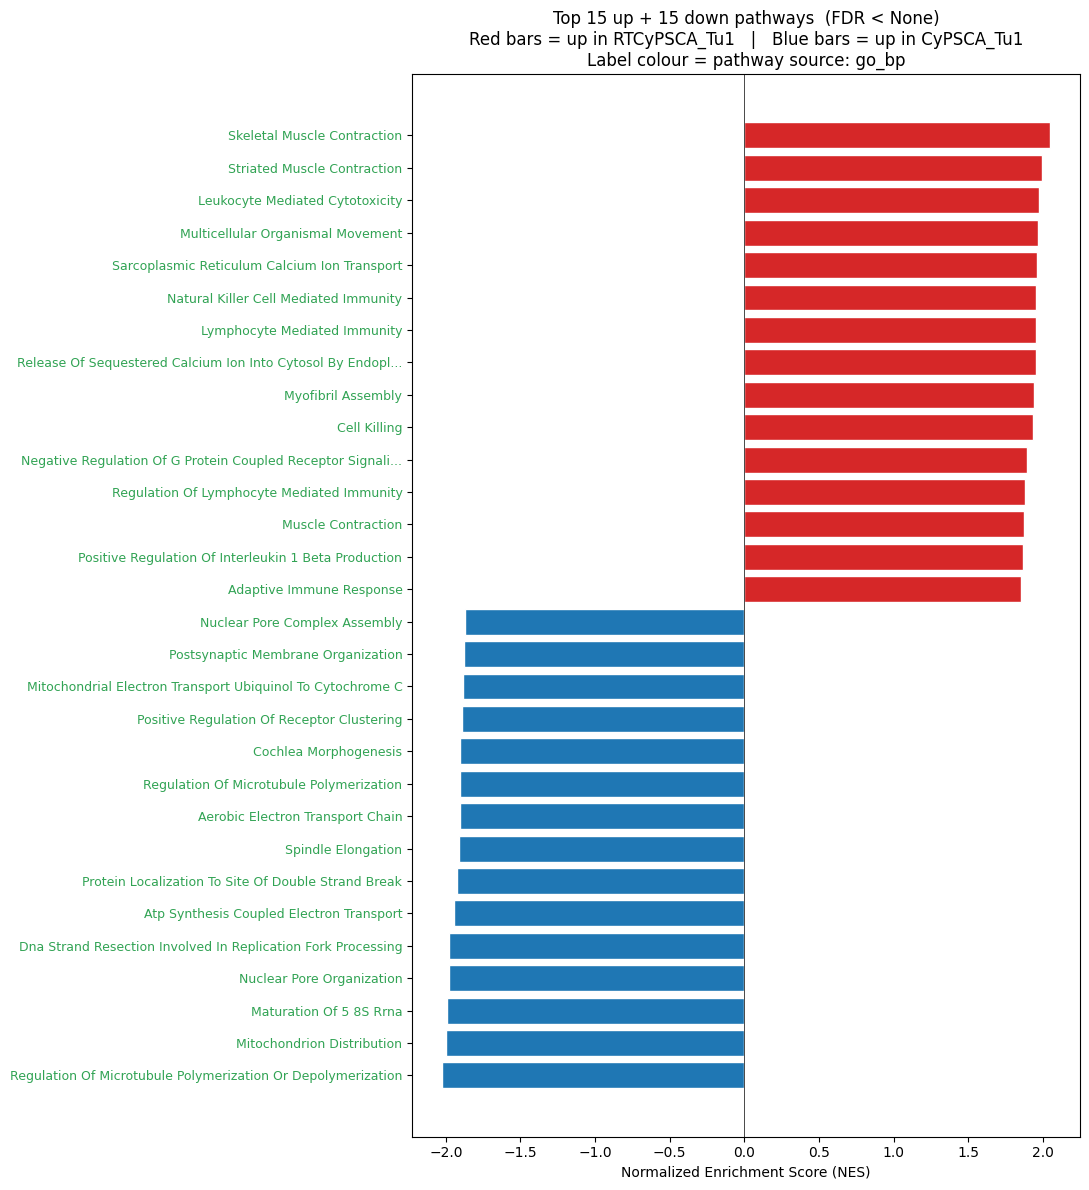

In [46]:
# ── Editable ──────────────────────────────────────────────────────────────────
n_each       = 15
fdr_cutoff   = None#0.25     # set to None to keep all
clean_names  = True     # strip prefixes like HALLMARK_ and Title-Case
# ─────────────────────────────────────────────────────────────────────────────

g = gsea_df.copy()
if fdr_cutoff is not None:
    g = g[g[fdr_col] < fdr_cutoff]

top_up   = g.nlargest(n_each, "NES")
top_down = g.nsmallest(n_each, "NES")

if len(top_up) < n_each or len(top_down) < n_each:
    print(f"Only {len(top_up)} up and {len(top_down)} down pathways passed FDR < {fdr_cutoff}.")

combined = pd.concat([top_up, top_down]).sort_values("NES")

def _clean(name):
    s = name
    for prefix in ("HALLMARK_", "REACTOME_", "GOBP_", "GOMF_", "GOCC_", "KEGG_"):
        if s.startswith(prefix):
            s = s[len(prefix):]
            break
    s = s.replace("_", " ").title()
    if len(s) > 60:
        s = s[:57] + "..."
    return s

combined["display"] = combined["pathway"].apply(_clean) if clean_names else combined["pathway"]

source_colors = {
    "hallmark": "#e6550d",
    "reactome": "#3182bd",
    "go_bp":    "#31a354",
}

fig, ax = plt.subplots(figsize=(11, 0.35 * len(combined) + 1.5))
y = np.arange(len(combined))
bar_colors = ["#d62728" if v > 0 else "#1f77b4" for v in combined["NES"]]
ax.barh(y, combined["NES"], color=bar_colors, edgecolor="white")

# Tick label colour by source library
ytick_colors = [source_colors.get(s, "black") for s in combined["source"]]
ax.set_yticks(y)
ax.set_yticklabels(combined["display"], fontsize=9)
for tick, c in zip(ax.get_yticklabels(), ytick_colors):
    tick.set_color(c)

ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Normalized Enrichment Score (NES)")
ax.set_title(
    f"Top {n_each} up + {n_each} down pathways  (FDR < {fdr_cutoff})\n"
    f"Red bars = up in {condition_a}   |   Blue bars = up in {condition_b}\n"
    f"Label colour = pathway source: " +
    "  ".join(f"{lib}" for lib in selected_libs if lib in source_colors)
)
plt.tight_layout()
plt.show()

fig.savefig(
    outdir / f"GSEA_top{n_each*2}_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.png",
    dpi=200,
    bbox_inches="tight",
)